# Homework 2 - Nurul - Q4,5,6

In [1]:
#| warning: false

library(dplyr)
library(lubridate)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




## Read & Prepare Data

In [2]:
df = read.csv("sp500_2023_2024.csv")

head(df)

,tic,datadate,conm,exchg,sic,cshtrd,prccd,prchd,prcld,prcod,gvkey
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,PNW,03/01/2023,PINNACLE WEST CAPITAL CORP,11,4911,1442534,74.63,76.4125,73.380,76.25,1075
2,PNW,04/01/2023,PINNACLE WEST CAPITAL CORP,11,4911,954218,75.39,76.0950,74.630,75.10,1075
3,PNW,05/01/2023,PINNACLE WEST CAPITAL CORP,11,4911,994775,73.65,75.0950,73.305,74.88,1075
4,PNW,06/01/2023,PINNACLE WEST CAPITAL CORP,11,4911,729808,75.46,76.0200,74.480,74.49,1075
5,PNW,09/01/2023,PINNACLE WEST CAPITAL CORP,11,4911,656127,75.55,76.4800,75.240,75.24,1075
6,PNW,10/01/2023,PINNACLE WEST CAPITAL CORP,11,4911,763254,75.65,75.6950,74.880,75.31,1075


In [3]:
# sort the data by tic and datadate

df <- df  %>% 
    arrange(tic, datadate)

## 4. Display the total trading volume of the top 3 exchanges by largest total trading volume, in a table.

There are 3 different exchanges in the data: exchange number 11, 14, and 21.
- `11` has the largest volume of `681415756062`
- 
- 

In [4]:
### check unique exchange
unique(df$exchg)

[1] 11 14 21

In [5]:
#| tbl-cap: Top 3 Exchanges by Total Trading Volume

### sum trading value
df_top3_exhange_trading_volume <- df  %>% 
    group_by(exchg)  %>% 
    summarise(total_trading_volume = sum(cshtrd))  %>% 
    ungroup()  %>% 
    arrange(desc(total_trading_volume))  %>% 
    head(3)

df_top3_exhange_trading_volume

exchg,total_trading_volume
<int>,<dbl>
11,681415756062
14,570830885382
21,385399362


## 5. Visualise the total trading volume of the top 3 exchanges by largest total trading volume, in a bar plot.

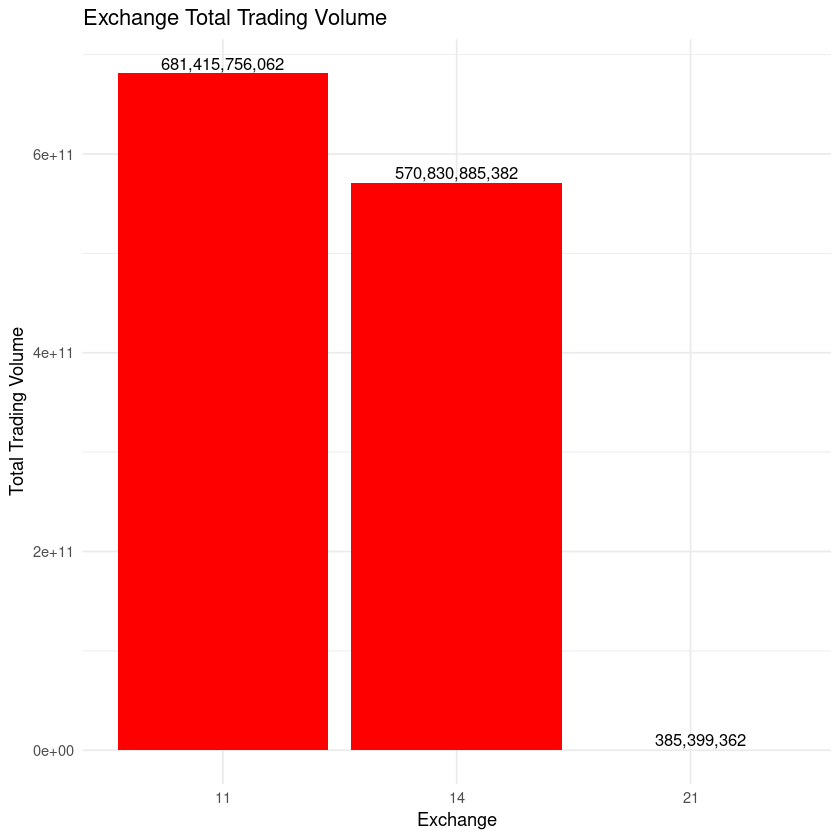

In [19]:
#| fig-cap: Top 3 Exchanges by Total Trading Volume

ggplot(df_top3_exhange_trading_volume, aes(x=factor(exchg), y=total_trading_volume))+
    geom_bar(stat="identity", fill="red")+
    geom_text(aes(label=format(total_trading_volume, big.mark=",")), vjust=-0.3, size=3.5)+
    theme_minimal()+
    labs(title="Exchange Total Trading Volume", x="Exchange", y="Total Trading Volume")

## 6. How many companies have more than one ticker?

There are 3 companies that have more than 1 tickers:
1. Alphabet Inc
2. Fox Corp
3. News Corp

In [33]:
#| tbl-cap: Companies with more than 1 tickers

df_company_ticker_count <- df  %>% 
    group_by(conm)  %>% 
    summarize(unique_tic = n_distinct(tic))  %>% 
    ungroup()

df_company_ticker_nonunique <- df_company_ticker_count %>% 
    filter(unique_tic > 1)

df_company_ticker_nonunique

conm,unique_tic
<chr>,<int>
ALPHABET INC,2
FOX CORP,2
NEWS CORP,2


In [32]:
nrow(df_company_ticker_nonunique)

[1] 3